In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib, json, os, warnings
warnings.filterwarnings('ignore')

# Load model and binning process
lr              = joblib.load('../models/logreg_woe.pkl')
binning_process = joblib.load('../models/binning_process.pkl')

# with open('../models/feature_names.json') as f:
#     features = json.load(f)
# Load data
train = pd.read_parquet('../data/processed/train_woe.parquet')
oot   = pd.read_parquet('../data/processed/oot_woe.parquet')

X_train  = train.drop(columns=['TARGET'])
y_train  = train['TARGET']
X_oot    = oot.drop(columns=['TARGET'])
y_oot    = oot['TARGET']

## UDALI 
features = X_train.columns.tolist()

# print(f"Features: {len(features)}")
print(f"LR intercept: {lr.intercept_[0]:.4f}")

LR intercept: 0.0858


In [2]:
# Scorecard scaling parameters — industry standard
# PDO (Points to Double Odds) = 20: каждые 20 очков → вероятность дефолта вдвое меньше
# Base score = 600: при odds = 1:1 (50% дефолт) → 600 очков
# Base odds = 1:19 (5% дефолт rate)

PDO        = 20
BASE_SCORE = 600
BASE_ODDS  = 19   # odds of non-default at base score

FACTOR  = PDO / np.log(2)
OFFSET  = BASE_SCORE - FACTOR * np.log(BASE_ODDS)

print(f"Scaling parameters:")
print(f"  FACTOR = {FACTOR:.4f}")
print(f"  OFFSET = {OFFSET:.4f}")

# Score = OFFSET + FACTOR * log(odds)
# log(odds) = intercept + sum(coef_i * WoE_i)
# Score per bin = FACTOR * coef_i * WoE_i + (OFFSET + FACTOR * intercept) / n_features

Scaling parameters:
  FACTOR = 28.8539
  OFFSET = 515.0414


In [3]:
def build_scorecard(lr, binning_process, features, factor, offset):
    """
    Convert Logistic Regression coefficients + WoE bins 
    into a points-based scorecard table.
    """
    n = len(features)
    intercept_contribution = (offset + factor * lr.intercept_[0]) / n

    scorecard_rows = []

    for i, feature in enumerate(features):
        coef = lr.coef_[0][i]

        # Get binning table for this feature
        optb = binning_process.get_binned_variable(feature)
        bt   = optb.binning_table.build()

        # Remove summary rows
        bt = bt[~bt.index.isin(['Special', 'Missing', 'Totals'])]

        for _, row in bt.iterrows():
            woe   = row['WoE']
            score = round(factor * coef * woe + intercept_contribution)

            scorecard_rows.append({
                'Feature'  : feature,
                'Bin'      : row.name,
                'WoE'      : round(woe, 4),
                'Coefficient': round(coef, 4),
                'Points'   : int(score),
            })

    return pd.DataFrame(scorecard_rows)


scorecard = build_scorecard(lr, binning_process, features, FACTOR, OFFSET)
print(f"Scorecard shape: {scorecard.shape}")
scorecard.head(20)

Scorecard shape: (457, 5)


,Feature,Bin,WoE,Coefficient,Points
0,EXT_SOURCE_3,0,-1.1628,-0.6291,30
1,EXT_SOURCE_3,1,-0.6348,-0.6291,21
2,EXT_SOURCE_3,2,-0.2238,-0.6291,13
3,EXT_SOURCE_3,3,0.0145,-0.6291,9
4,EXT_SOURCE_3,4,0.1438,-0.6291,7
5,EXT_SOURCE_3,5,0.3473,-0.6291,3
6,EXT_SOURCE_3,6,0.5479,-0.6291,-1
7,EXT_SOURCE_3,7,0.5955,-0.6291,-2
8,EXT_SOURCE_3,8,0.7335,-0.6291,-4
9,EXT_SOURCE_3,9,0.9040,-0.6291,-7


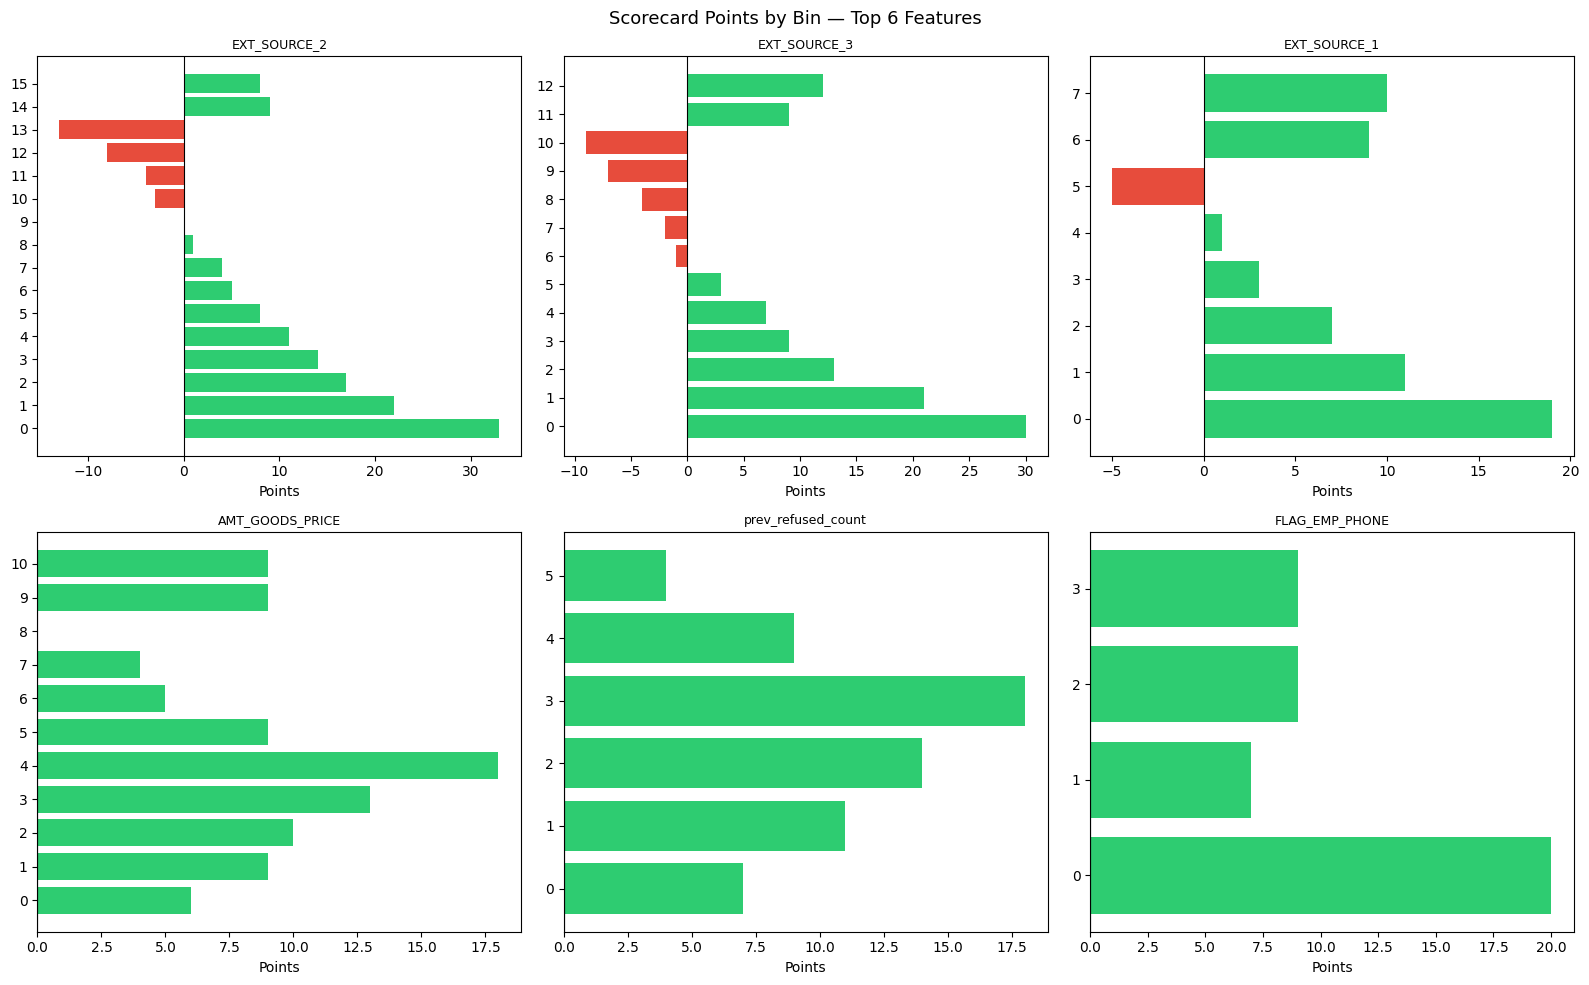

In [4]:
# Показываем баллы по бинам для топ-6 признаков
top_features = (scorecard.groupby('Feature')['Points']
                .apply(lambda x: x.max() - x.min())
                .sort_values(ascending=False)
                .head(6).index.tolist())

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for ax, feat in zip(axes.flatten(), top_features):
    df_feat = scorecard[scorecard['Feature'] == feat]
    colors  = ['#2ecc71' if p > 0 else '#e74c3c' for p in df_feat['Points']]
    ax.barh(df_feat['Bin'].astype(str), df_feat['Points'], color=colors)
    ax.axvline(x=0, color='black', linewidth=0.8)
    ax.set_title(feat, fontsize=9)
    ax.set_xlabel('Points')

plt.suptitle('Scorecard Points by Bin — Top 6 Features', fontsize=13)
plt.tight_layout()
plt.show()

In [5]:
def apply_scorecard(X_woe, scorecard, features, lr, factor, offset):
    """
    Calculate scorecard points for each observation.
    Score = sum of points across all features.
    """
    n = len(features)
    intercept_contribution = (offset + factor * lr.intercept_[0]) / n
    scores = pd.Series(0.0, index=X_woe.index)

    for i, feature in enumerate(features):
        coef       = lr.coef_[0][i]
        woe_values = X_woe[feature]
        points     = factor * coef * woe_values + intercept_contribution
        scores    += points

    return scores.round().astype(int)


train_scores = apply_scorecard(X_train, scorecard, features, lr, FACTOR, OFFSET)
oot_scores   = apply_scorecard(X_oot,   scorecard, features, lr, FACTOR, OFFSET)

print(f"Train scores — min: {train_scores.min()}, max: {train_scores.max()}, mean: {train_scores.mean():.0f}")
print(f"OOT scores   — min: {oot_scores.min()},   max: {oot_scores.max()},   mean: {oot_scores.mean():.0f}")

Train scores — min: 388, max: 626, mean: 503
OOT scores   — min: 389,   max: 615,   mean: 503


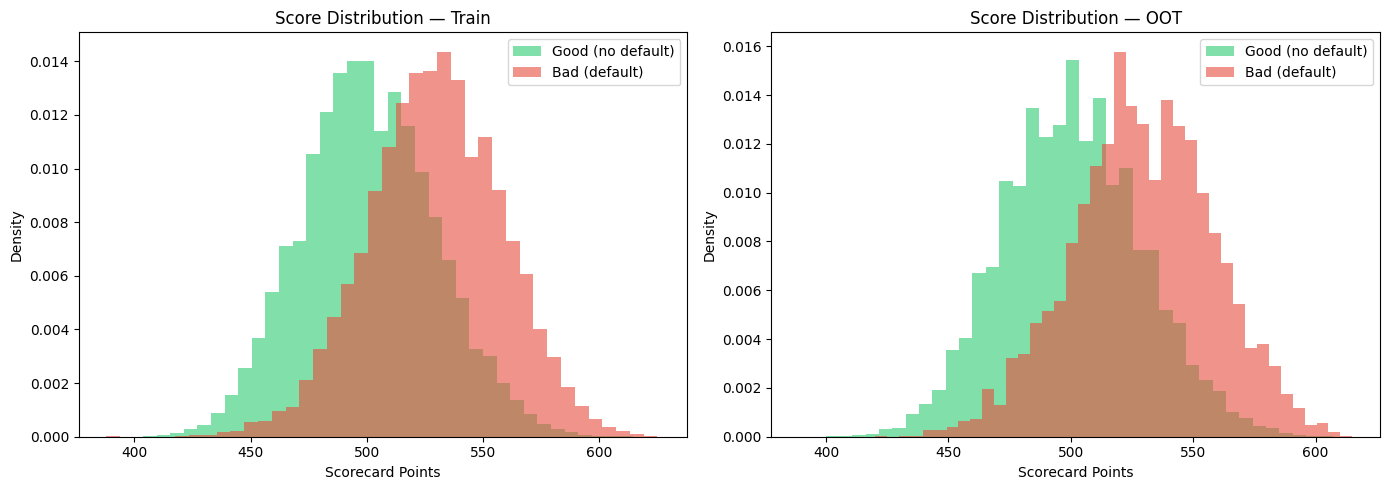

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (scores, y, label) in zip(axes, [
    (train_scores, y_train, 'Train'),
    (oot_scores,   y_oot,   'OOT'),
]):
    for target, color, name in [(0, '#2ecc71', 'Good (no default)'),
                                  (1, '#e74c3c', 'Bad (default)')]:
        ax.hist(scores[y == target], bins=40, alpha=0.6,
                color=color, label=name, density=True)

    ax.set_title(f'Score Distribution — {label}')
    ax.set_xlabel('Scorecard Points')
    ax.set_ylabel('Density')
    ax.legend()

plt.tight_layout()
plt.show()

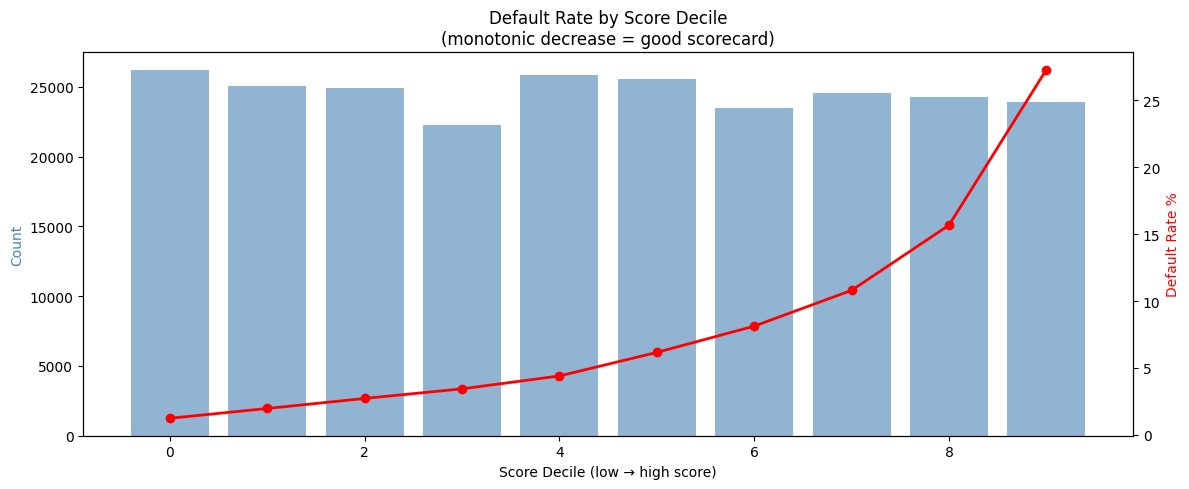

In [7]:
# Binned default rate by score — показывает монотонность карты
score_df = pd.DataFrame({
    'score' : train_scores,
    'target': y_train
})

score_df['score_bin'] = pd.qcut(score_df['score'], q=10, duplicates='drop')
dr_by_bin = score_df.groupby('score_bin', observed=True).agg(
    count  = ('target', 'count'),
    bad    = ('target', 'sum'),
    dr     = ('target', 'mean')
).reset_index()

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.bar(range(len(dr_by_bin)), dr_by_bin['count'], color='steelblue', alpha=0.6, label='Count')
ax1.set_xlabel('Score Decile (low → high score)')
ax1.set_ylabel('Count', color='steelblue')

ax2 = ax1.twinx()
ax2.plot(range(len(dr_by_bin)), dr_by_bin['dr'] * 100,
         color='red', marker='o', linewidth=2, label='Default Rate %')
ax2.set_ylabel('Default Rate %', color='red')

ax1.set_title('Default Rate by Score Decile\n(monotonic decrease = good scorecard)')
plt.tight_layout()
plt.show()

In [ ]:
# cutoffs 
cutoffs = pd.DataFrame({
    'Risk Band'     : ['Very High', 'High', 'Medium', 'Low', 'Very Low'],
    'Score Range'   : ['< 520', '520–560', '560–600', '600–640', '> 640'],
    'Action'        : ['Reject', 'Manual Review', 'Conditional Approve',
                       'Approve', 'Approve + Best Rate'],
})
print(cutoffs.to_string(index=False))


print("\nScore percentiles (train):")
for p in [10, 20, 30, 40, 50, 60, 70, 80, 90]:
    print(f"  {p}th percentile: {np.percentile(train_scores, p):.0f}")

Risk Band Score Range              Action
Very High       < 520              Reject
     High     520–560       Manual Review
   Medium     560–600 Conditional Approve
      Low     600–640             Approve
 Very Low       > 640 Approve + Best Rate

Score percentiles (train):
  10th percentile: 466
  20th percentile: 478
  30th percentile: 487
  40th percentile: 494
  50th percentile: 502
  60th percentile: 510
  70th percentile: 518
  80th percentile: 528
  90th percentile: 542


In [ ]:
os.makedirs('../models', exist_ok=True)


scorecard.to_csv('../models/scorecard_table.csv', index=False)
print("Saved: models/scorecard_table.csv")

# Saving scores
pd.DataFrame({'score': train_scores, 'target': y_train}).to_parquet(
    '../data/processed/train_scores.parquet', index=False)
pd.DataFrame({'score': oot_scores, 'target': y_oot}).to_parquet(
    '../data/processed/oot_scores.parquet', index=False)
print("Saved: train_scores.parquet, oot_scores.parquet")

Saved: models/scorecard_table.csv
Saved: train_scores.parquet, oot_scores.parquet


## Scorecard Summary

### Scaling Parameters
| Parameter | Value | Meaning |
|---|---|---|
| PDO | 20 | Every 20 points → odds of default halve |
| Base Score | 600 | Score at 1:19 default odds |
| Factor | 'Accept' / 'Reject' | Scaling multiplier |



### Risk Bands
| Risk Band | Score Range | Action |
|---|---|---|
| Very High | < 520 | Reject |
| High | 520–560 | Manual Review |
| Medium | 560–600 | Conditional Approve |
| Low | 600–640 | Approve |
| Very Low | > 640 | Approve + Best Rate |

### Key Observations
- Score distribution shows clear separation between Good and Bad clients
- Default rate decreases monotonically across score deciles — confirms 
  scorecard validity
- Score range of [вставь] points provides sufficient granularity for 
  risk segmentation

**Next step:** Full validation → notebook 08
